# 10 注意力机制

## 10.1 注意力提示

环境中存在大量的干扰注意力的信息。

在两种提示的影响下，人类可以有选择地引导注意力的焦点：

- **自主性提示（Volitional Cues）** ：

自主性提示是指有意识地，主动地根据当前任务的需要来引导注意力的提示。

- **非自主性提示（Non-volitional Cues）** ：

非自主性提示是指不依赖于任务，而是由输入数据本身的特点自动捕获注意力的提示。

在神经网络的注意力机制中，通常将自主性提示称为 **查询（query）** ，将非自主性提示称为 **键（value）** 。注意力机制将查询和键统一喂给 **注意力汇聚（attention pooling）** ，这些查询和键将进行匹配，得出最终的希望的输入，类似人类的感官输入，称为 **值（value）** 。

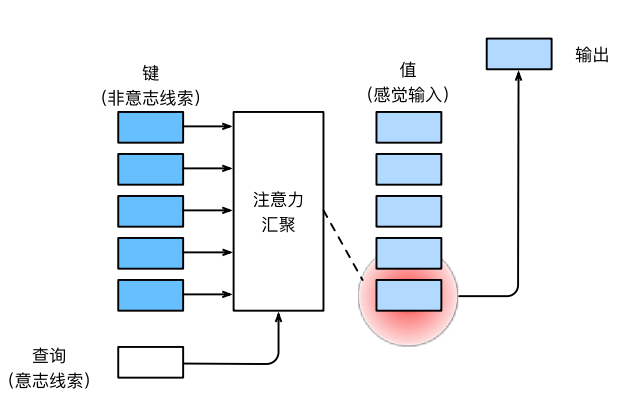

## 10.2 注意力汇聚

#### 注意力汇聚基础 4 步

1. **计算匹配度** ：

考虑 **查询 × 键** 形状的矩阵。对于每个查询，即每个整行，需要给每个键都去打一个分数，称为匹配度。

2. **归一化权重** ：

对于每个查询，即每个整行，将所有分数进行归一化，使得它们被转化为行总和为 1 的权重。

3. **加权（平均）** ：

（已归一化，无需平均）对于每个查询，即每个整行，将所有分数加权求和，最终得到一个综合特征分数。根据这个分数取得最贴近的键对应的值。

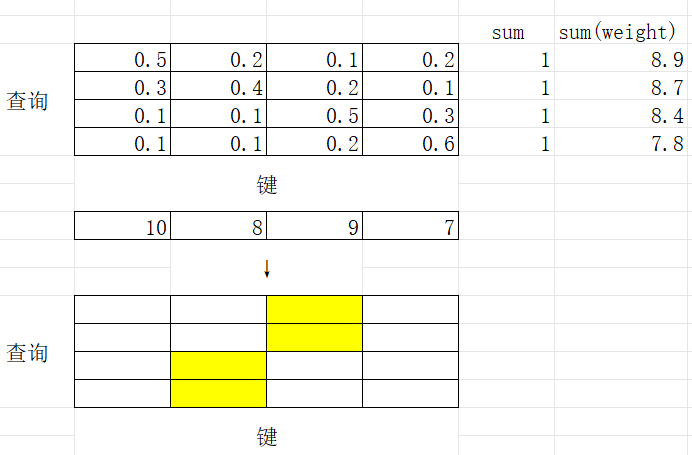

如例所示，上面是注意力权重图，下面是最终选择的查询对应的键。在注意力机制的数据可视化中，还会将上面的权重矩阵绘制成热力图：

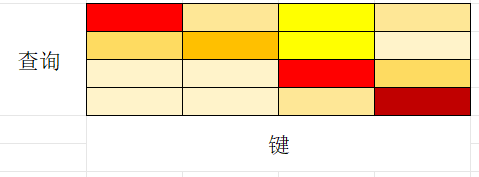

#### Nadaraya-Watson 核回归

上面得到的注意力权重进行加权的方式，是基于 Nadaraya-Watson 核回归 重写得到的。重写后的注意力汇聚的公式可以具象为：

$$
f(x) = \sum_{i=1}^n \alpha(x, x_i) y_i
$$

$\alpha(x,x_i)$ 即是对于每个 $y_i$ 分配的权重。在归一化之前（或者在该公式中加入平均操作），每个 $y_i$ 对应的权重 $K$ 称为 **核（kernel）** 。

基于这里的 $\alpha$ 是否可学习，注意力汇聚可以分为非参数型和带参数型。 

#### 注意力评分函数

$\alpha$ 是基于键和查询（ $(x,x_i)$ ）的向注意力评分（归一化后）的映射，它即可以看做 **注意力评分函数（attention scoring function，评分函数（scoring function））** 。

选择不同的注意力评分函数 $\alpha$ 会导致不同的注意力汇聚操作，下面有两个流行的评分函数：



1. **掩蔽 softmax 操作** ： 

在批量处理中，不同序列长度不同，通常用填充（padding）使长度一致，掩蔽 softmax 可以忽略这些填充位置。

给定一个输入向量（或矩阵） $x$ 和一个掩码 $mask$ （与x形状相同），对需要掩蔽的位置，将 $x$ 的对应元素设置为一个极小的值（如 $-1e9$ ），这样在计算 softmax 时，这些位置的指数值接近于 $0$ ，然后计算标准的 softmax 函数。



2. **加性注意力（additive attention）** ：

给定查询 $\mathbf{q} \in \mathbb{R}^{q}$ 和键 $\mathbf{k} \in \mathbb{R}^{k}$，加性注意力（additive attention）的评分函数为：

$$
a(\mathbf{q}, \mathbf{k}) = \mathbf{w}_v^\top \tanh(\mathbf{W}_q \mathbf{q} + \mathbf{W}_k \mathbf{k}) \in \mathbb{R}, \tag{10.3.3}
$$

其中可学习的参数是 $\mathbf{W}_q \in \mathbb{R}^{h \times q}$、$\mathbf{W}_k \in \mathbb{R}^{h \times k}$ 和 $\mathbf{w}_v \in \mathbb{R}^{h}$。如 (10.3.3) 所示，将查询和键连结起来后输入到一个多层感知机（MLP）中，感知机包含一个隐藏层，其隐藏单元数是一个超参数 $h$。通过使用 $\tanh$ 作为激活函数，并且禁用偏置项。

*注：其中 $\mathbf{W_q} \mathbf{q}$ 和 $\mathbf{W_k} \mathbf{k}$ 形状为 $h \times 1$*

3. **缩放点积注意力（Scaled Dot-Product Attention）** ：

*注：点积能够反映两个向量之间的相似程度（固定长度，相同方向下点积最大）*

若查询和键的元素是均值为0、方差为1的独立随机变量，它们的点积均值为0、方差为查询和键的长度d。 **向量越长，点积方差越大，容易导致 softmax 后梯度消失或爆炸** 。

*注： $E[\sum X_i Y_i]=\sum E[X_i]E[Y_i]$ ， $D\left[\sum_{i=1}^n X_i Y_i\right] = \sum_{i=1}^n D[X_i Y_i] = \sum_{i=1}^n 1 = n$*

因此，缩放点积注意力需要 **将点积结果除以 $\sqrt{d}$** 来缩放，使点积方差稳定为1。

## 10.4 Bahdanau 注意力